In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("sales_bi.db")

In [3]:
import os
print(os.getcwd())

C:\Users\spenc


In [5]:
import sqlite3
conn = sqlite3.connect("sales_bi.db")

query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql(query, conn)

,name


In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\spenc\OneDrive\Desktop\sales_bi.db")
query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql(query, conn)

,name
0,sales_data


In [9]:
pd.read_sql("SELECT * FROM sales_data LIMIT 5;", conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
query = """
SELECT Region, ROUND(SUM(Sales), 2) AS total_sales
FROM sales_data
GROUP BY Region
ORDER BY total_sales DESC;
"""

region_sales = pd.read_sql(query, conn)
region_sales

,Region,total_sales
0,West,710219.68
1,East,669518.73
2,Central,492646.91
3,South,389151.46


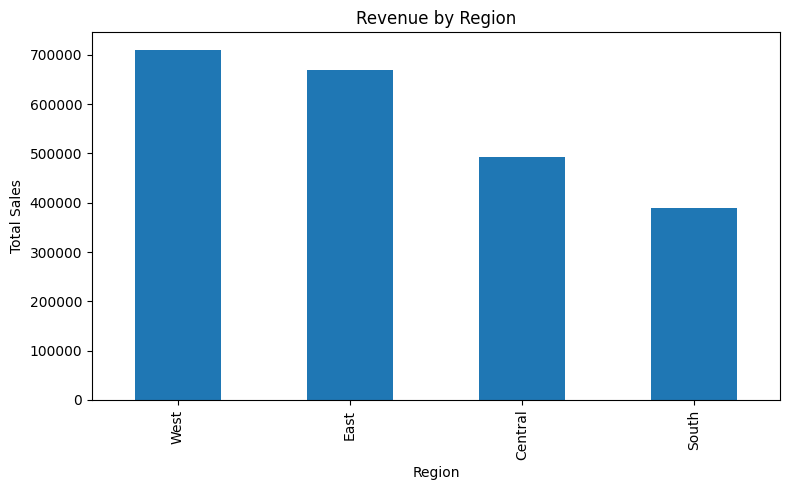

In [12]:
import matplotlib.pyplot as plt

region_sales.plot(kind="bar", x="Region", y="total_sales", legend=False, figsize=(8,5))

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("revenue_by_region.png")

plt.show()

In [14]:
query = """
SELECT Category, ROUND(SUM(Sales), 2) AS total_sales
FROM sales_data
GROUP BY Category
ORDER BY total_sales DESC;
"""

category_sales = pd.read_sql(query, conn)

category_sales

,Category,total_sales
0,Technology,827455.87
1,Furniture,728658.58
2,Office Supplies,705422.33


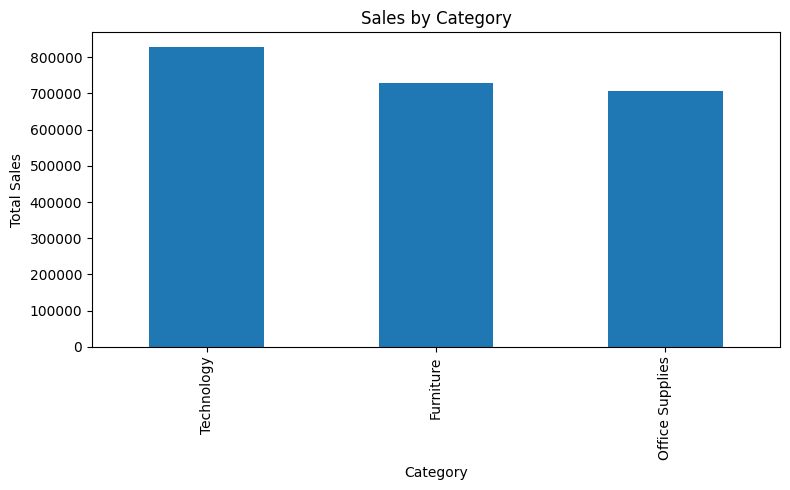

In [15]:
category_sales.plot(kind="bar", x="Category", y="total_sales", legend=False, figsize=(8,5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("sales_by_category.png")

plt.show()

In [16]:
query = """
SELECT "Customer Name", ROUND(SUM(Sales), 2) AS total_sales
FROM sales_data
GROUP BY "Customer Name"
ORDER BY total_sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, conn)

top_customers

,Customer Name,total_sales
0,Sean Miller,25043.05
1,Tamara Chand,19052.22
2,Raymond Buch,15117.34
3,Tom Ashbrook,14595.62
4,Adrian Barton,14473.57
5,Ken Lonsdale,14175.23
6,Sanjit Chand,14142.33
7,Hunter Lopez,12873.30
8,Sanjit Engle,12209.44
9,Christopher Conant,12129.07


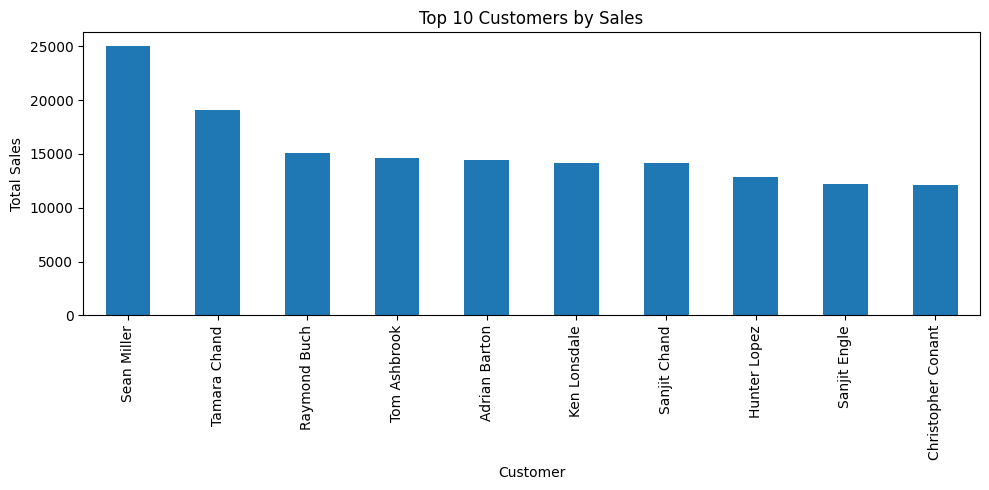

In [17]:
top_customers.plot(kind="bar", x="Customer Name", y="total_sales", legend=False, figsize=(10,5))

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.savefig("top_customers.png")

plt.show()

In [18]:
query = """
SELECT SUBSTR("Order Date",1,7) AS month,
ROUND(SUM(Sales),2) AS total_sales
FROM sales_data
GROUP BY month
ORDER BY month;
"""

monthly_sales = pd.read_sql(query, conn)

monthly_sales

,month,total_sales
0,01/01/2,1481.83
1,01/02/2,630.87
2,01/03/2,10131.13
3,01/04/2,8254.36
4,01/05/2,5077.18
...,...,...
360,31/05/2,6390.70
361,31/07/2,7444.35
362,31/08/2,5881.11
363,31/10/2,12847.46


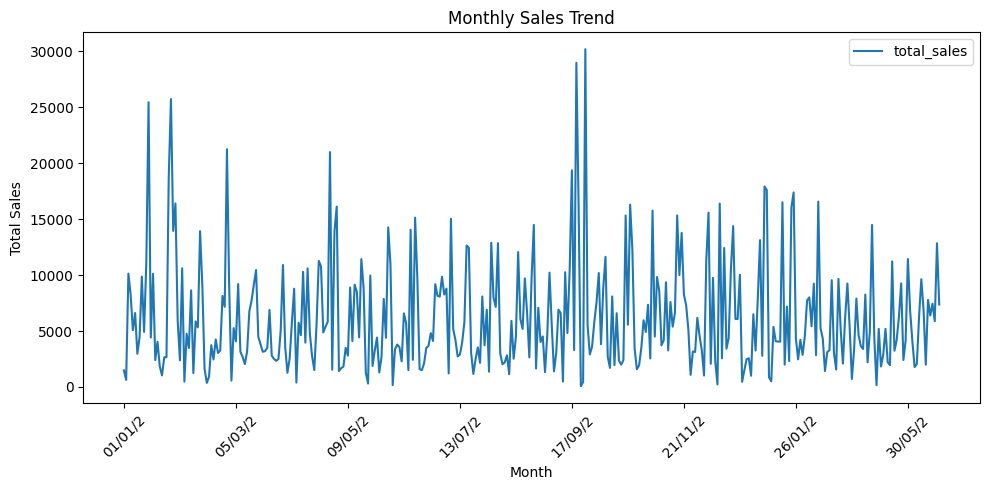

In [19]:
monthly_sales.plot(kind="line", x="month", y="total_sales", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("monthly_sales_trend.png")

plt.show()

In [21]:
query = """
SELECT "Product Name", ROUND(SUM(Sales), 2) AS total_sales
FROM sales_data
GROUP BY "Product Name"
ORDER BY total_sales DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, conn)

top_products

,Product Name,total_sales
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50
6,Hewlett Packard LaserJet 3310 Copier,18839.69
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90
8,GBC DocuBind P400 Electric Binding System,17965.07
9,High Speed Automatic Electric Letter Opener,17030.31


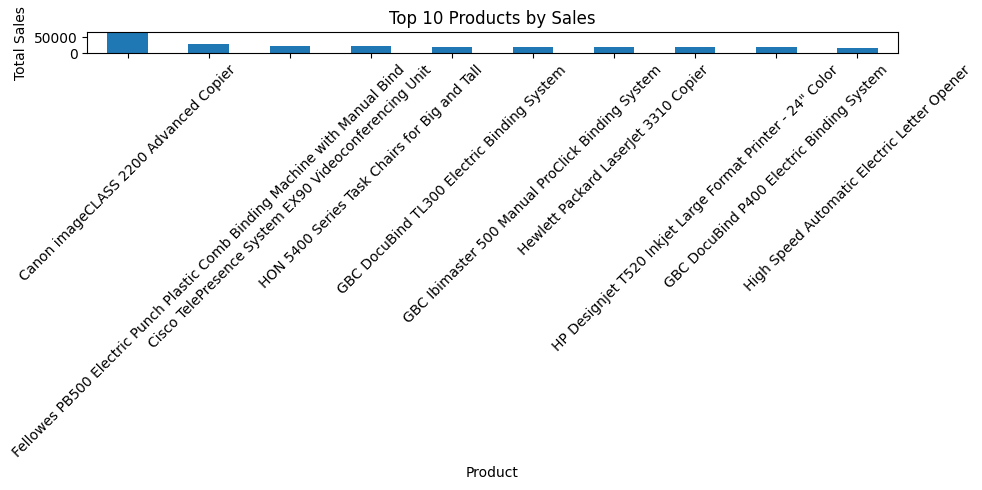

In [22]:
top_products.plot(kind="bar", x="Product Name", y="total_sales", legend=False, figsize=(10,5))

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("top_products.png")

plt.show()